# 📊 Exploratory Data Analysis — Credit Risk Engine
**13 data sources | Real organisational data | Step-by-step profiling**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
print('Libraries loaded')

Libraries loaded


## 1. Load All 13 Sources

In [5]:
import os
RAW = 'D:/Data Analyst/Projects/Credit_Risk_Engine_Project/credit-risk-engine-v2/credit-risk-engine/data/raw'

files = {
    'customer':   'CUSTOMER_MASTER.csv',
    'loan':       'LOAN_MASTER_DAILY.csv',
    'app':        'APPLICATION_FORM_DATA.csv',
    'bureau':     'CIBIL_RAW_PULL.csv',
    'brefresh':   'BUREAU_REFRESH_6M.csv',
    'bank':       'BANK_STATEMENT_SUMMARY.csv',
    'income':     'INCOME_DOCUMENT_PARSED.csv',
    'dpd':        'DPD_HISTORY_MONTHLY.csv',
    'portfolio':  'ACCOUNT_PORTFOLIO_MONTHLY.csv',
    'repay':      'REPAYMENT_TRANSACTIONS.csv',
    'settle':     'SETTLEMENT_CASES.csv',
    'writeoff':   'WRITE_OFF_DATA.csv',
    'disbursement': 'DISBURSEMENT_DETAILS.csv',
}

dfs = {}
for k, v in files.items():
    fp = os.path.join(RAW, v)
    if os.path.exists(fp):
        dfs[k] = pd.read_csv(fp, low_memory=False)
        print(f'  {k:15s} {dfs[k].shape[0]:>7,} rows x {dfs[k].shape[1]:>3} cols')
    else:
        print(f'  MISSING: {fp}')

  customer            400 rows x  19 cols
  loan                500 rows x  17 cols
  app                 400 rows x  21 cols
  bureau              400 rows x  22 cols
  brefresh          1,600 rows x  16 cols
  bank                400 rows x  23 cols
  income              400 rows x  15 cols
  dpd              10,800 rows x   9 cols
  portfolio         2,400 rows x  10 cols
  repay             4,578 rows x  12 cols
  settle               30 rows x  11 cols
  writeoff             40 rows x  11 cols
  disbursement        700 rows x   9 cols


## 2. Customer Demographics

In [7]:
cust = dfs['customer']
print('Shape:', cust.shape)
print('\nNull counts:')
print(cust.isnull().sum()[cust.isnull().sum()>0])
print('\nSample:')
cust.head(3)

Shape: (400, 19)

Null counts:
Series([], dtype: int64)

Sample:


,customer_id,cif_number,customer_name,dob,age,gender,marital_status,occupation_type,annual_income,city,state,pincode,pan_number,mobile_number,email_id,kyc_status,years_at_current_residence,own_rent_flag,load_date
0,2000000,CIF0002000000,Sneha Sankar,1996-07-21,28,Female,Unmarried,Contract Employee,7028210.08,Coimbatore,Tamil Nadu,372986,INTKS8471F,9901898947,ebobal@example.net,Re-KYC Due,17,Rented,2024-12-31
1,2000001,CIF0002000001,Ronith Hayre,1988-12-29,36,Female,Married,Salaried - Government,5960334.01,Howrah,West Bengal,676060,EOADC8431M,9295047890,karora@example.net,Verified - Branch,30,Owned,2024-12-31
2,2000002,CIF0002000002,Yashodhara Lata,1960-09-05,64,Male,Married,Self Employed - Non Professional,11145999.29,Howrah,West Bengal,279508,LFLSF4049A,9208243963,kadakiagaurav@example.com,Verified - Branch,25,Owned,2024-12-31


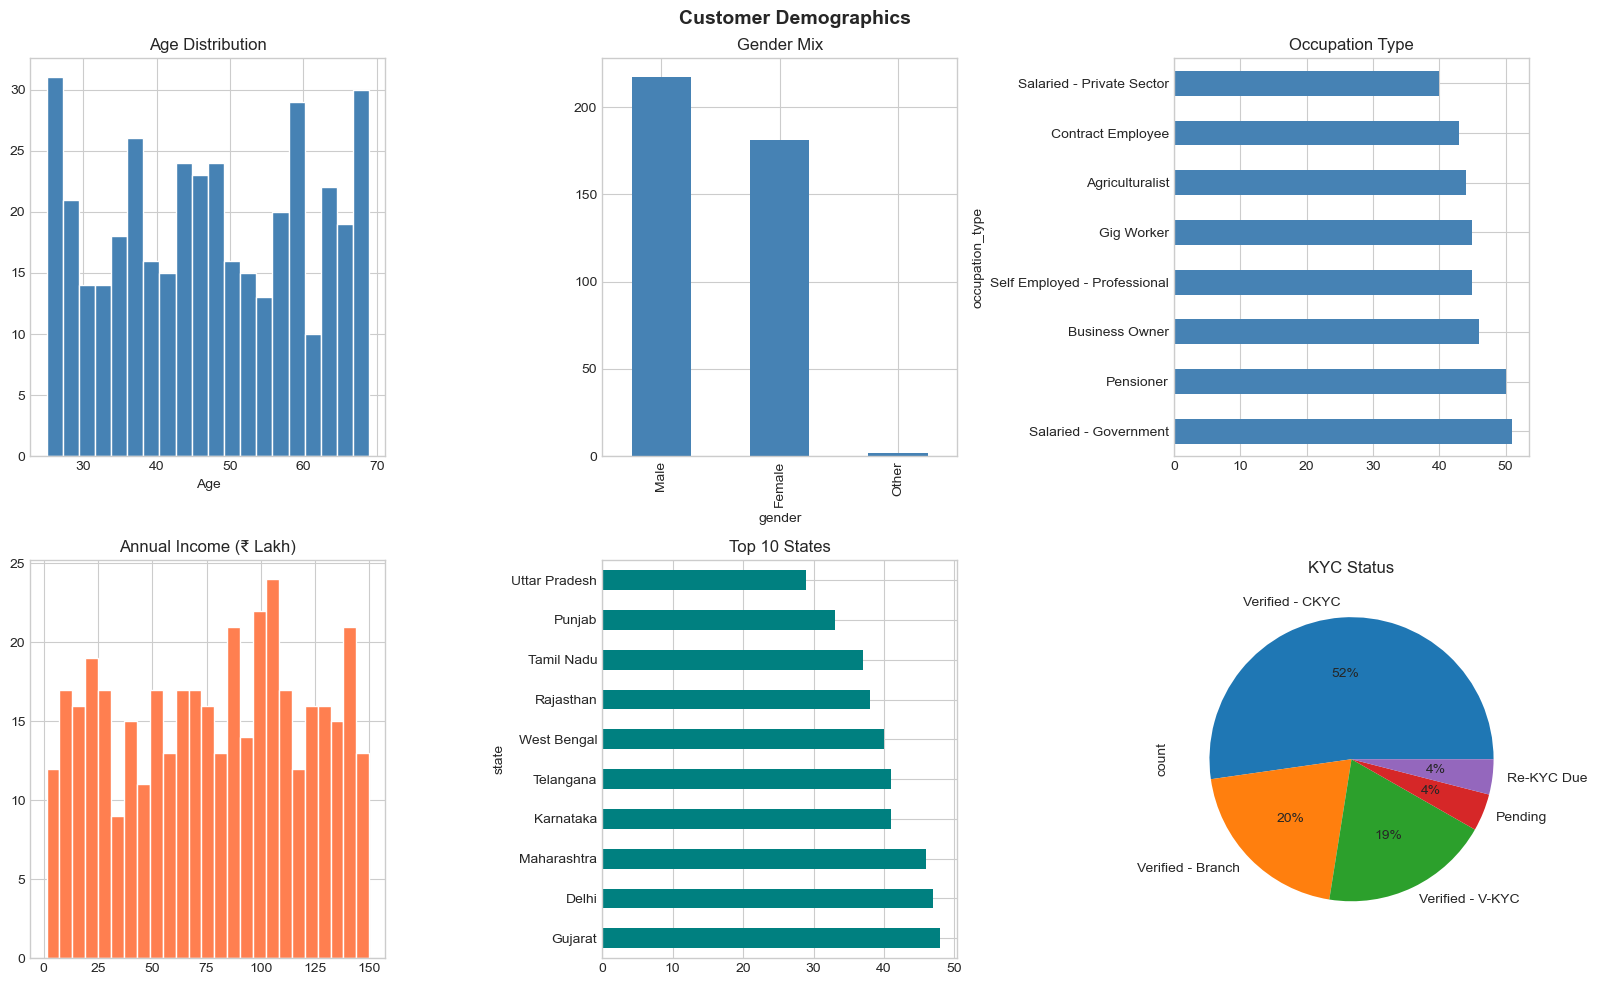

Saved: models/eda_demographics.png


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Demographics', fontsize=14, fontweight='bold')

cust['age'] = pd.to_numeric(cust['age'], errors='coerce')
cust['annual_income'] = pd.to_numeric(cust['annual_income'], errors='coerce')

axes[0,0].hist(cust['age'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution'); axes[0,0].set_xlabel('Age')

if 'gender' in cust.columns:
    cust['gender'].value_counts().plot(kind='bar', ax=axes[0,1], color='steelblue')
    axes[0,1].set_title('Gender Mix')

if 'occupation_type' in cust.columns:
    cust['occupation_type'].value_counts().head(8).plot(kind='barh', ax=axes[0,2], color='steelblue')
    axes[0,2].set_title('Occupation Type')

if 'annual_income' in cust.columns:
    axes[1,0].hist(cust['annual_income'].dropna()/1e5, bins=25, color='coral', edgecolor='white')
    axes[1,0].set_title('Annual Income (₹ Lakh)')

if 'state' in cust.columns:
    cust['state'].value_counts().head(10).plot(kind='barh', ax=axes[1,1], color='teal')
    axes[1,1].set_title('Top 10 States')

if 'kyc_status' in cust.columns:
    cust['kyc_status'].value_counts().plot(kind='pie', ax=axes[1,2], autopct='%1.0f%%')
    axes[1,2].set_title('KYC Status')

plt.tight_layout()
plt.savefig('D:/Data Analyst/Projects/Credit_Risk_Engine_Project/credit-risk-engine-v2/credit-risk-engine/models2/eda_demographics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: models/eda_demographics.png')

## 3. Loan Portfolio Analysis

In [21]:
loan = dfs['loan']
loan['sanction_amount'] = pd.to_numeric(loan['sanction_amount'], errors='coerce')
loan['interest_rate']   = pd.to_numeric(loan['interest_rate'],   errors='coerce')
loan['tenure_months']   = pd.to_numeric(loan['tenure_months'],   errors='coerce')

print('Portfolio Summary:')
print(f'  Total loans:      {len(loan):,}')
print(f'  Total AUM:        ₹{loan["sanction_amount"].sum()/1e7:.2f} Cr')
print(f'  Avg ticket size:  ₹{loan["sanction_amount"].mean()/1e5:.2f} Lakh')
print(f'  Avg interest rate:{loan["interest_rate"].mean():.2f}%')
print(f'  Avg tenure:       {loan["tenure_months"].mean():.1f} months')
if 'loan_status' in loan.columns:
    print('\nLoan Status:')
    print(loan['loan_status'].value_counts())

Portfolio Summary:
  Total loans:      500
  Total AUM:        ₹1288.08 Cr
  Avg ticket size:  ₹257.62 Lakh
  Avg interest rate:15.72%
  Avg tenure:       93.0 months

Loan Status:
loan_status
Active                  274
Closed - Matured         69
Closed - Pre-Payment     41
Settled                  24
Restructured             24
Written-Off              23
NPA - Sub-Standard       18
NPA - Loss               17
NPA - Doubtful           10
Name: count, dtype: int64


## 4. Bureau Score Distribution

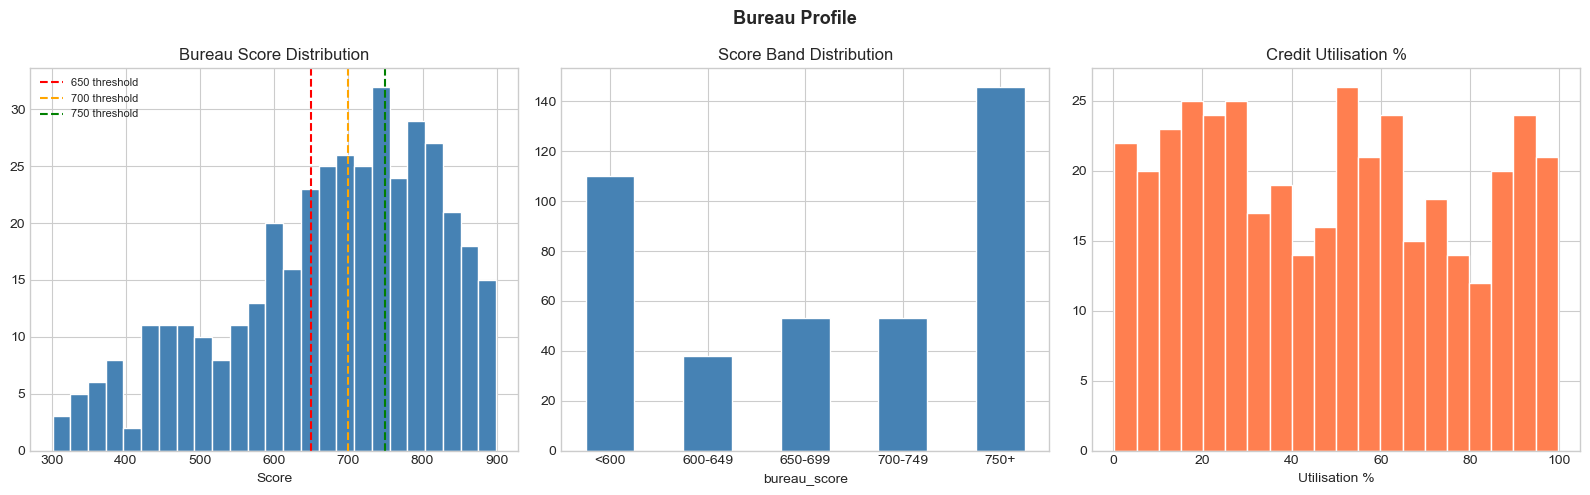

In [23]:
bur = dfs['bureau']
bur['bureau_score'] = pd.to_numeric(bur['bureau_score'], errors='coerce')
bur['credit_utilisation_pct'] = pd.to_numeric(bur['credit_utilisation_pct'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bureau Profile', fontsize=13, fontweight='bold')

axes[0].hist(bur['bureau_score'].dropna(), bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(650, color='red', linestyle='--', label='650 threshold')
axes[0].axvline(700, color='orange', linestyle='--', label='700 threshold')
axes[0].axvline(750, color='green', linestyle='--', label='750 threshold')
axes[0].set_title('Bureau Score Distribution')
axes[0].set_xlabel('Score'); axes[0].legend(fontsize=8)

bands = pd.cut(bur['bureau_score'], bins=[0,599,649,699,749,900],
               labels=['<600','600-649','650-699','700-749','750+'])
bands.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Score Band Distribution'); axes[1].tick_params(rotation=0)

axes[2].hist(bur['credit_utilisation_pct'].dropna(), bins=20, color='coral', edgecolor='white')
axes[2].set_title('Credit Utilisation %'); axes[2].set_xlabel('Utilisation %')

plt.tight_layout()
plt.savefig('D:/Data Analyst/Projects/Credit_Risk_Engine_Project/credit-risk-engine-v2/credit-risk-engine/models2/eda_bureau.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. DPD / Delinquency Analysis

DPD Summary:
  Total records:    10,800
  Unique loans:     300
  Max DPD ever:     335
  % records DPD>0:  73.86%
  % records DPD>=90:23.40%


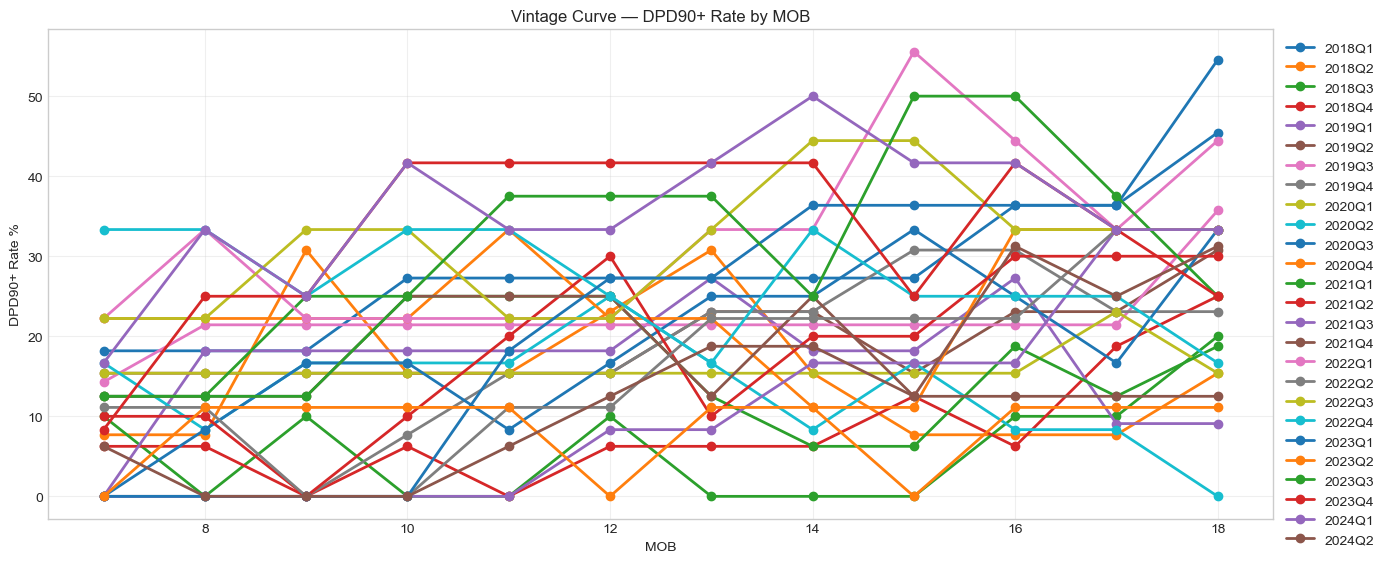

In [27]:
dpd = dfs['dpd']
dpd['dpd'] = pd.to_numeric(dpd['dpd'], errors='coerce').fillna(0)
dpd['mob'] = pd.to_numeric(dpd['mob'], errors='coerce').fillna(0)

print('DPD Summary:')
print(f'  Total records:    {len(dpd):,}')
print(f'  Unique loans:     {dpd["loan_id"].nunique():,}')
print(f'  Max DPD ever:     {dpd["dpd"].max()}')
print(f'  % records DPD>0:  {(dpd["dpd"]>0).mean()*100:.2f}%')
print(f'  % records DPD>=90:{(dpd["dpd"]>=90).mean()*100:.2f}%')

# Vintage analysis
loan_dates = dfs['loan'][['loan_id','disbursement_date']].copy()
loan_dates['disbursement_date'] = pd.to_datetime(loan_dates['disbursement_date'], errors='coerce')
dpd_v = dpd.merge(loan_dates, on='loan_id', how='left')
dpd_v['vintage'] = dpd_v['disbursement_date'].dt.to_period('Q').astype(str)

vintage_dpd90 = dpd_v[dpd_v['mob'].between(7,18)].groupby(['vintage','mob']).apply(
    lambda x: (x['dpd']>=90).mean()*100
).reset_index(name='dpd90_rate')

if len(vintage_dpd90) > 0:
    pivot = vintage_dpd90.pivot(index='mob', columns='vintage', values='dpd90_rate').fillna(0)
    plt.figure(figsize=(14, 6))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker='o', label=col, linewidth=2)
    plt.xlabel('MOB'); plt.ylabel('DPD90+ Rate %')
    plt.title('Vintage Curve — DPD90+ Rate by MOB')
    plt.legend(bbox_to_anchor=(1,1)); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('D:/Data Analyst/Projects/Credit_Risk_Engine_Project/credit-risk-engine-v2/credit-risk-engine/models2/eda_vintage.png', dpi=120, bbox_inches='tight')
    plt.show()

## 6. Target Variable Analysis

Target Distribution:
bad
1    155
0    145
Name: count, dtype: int64

Default Rate: 51.67%
  Loans in performance window: 300
  Bad (DPD90+ / Settled / WO): 155
  Good:                         145


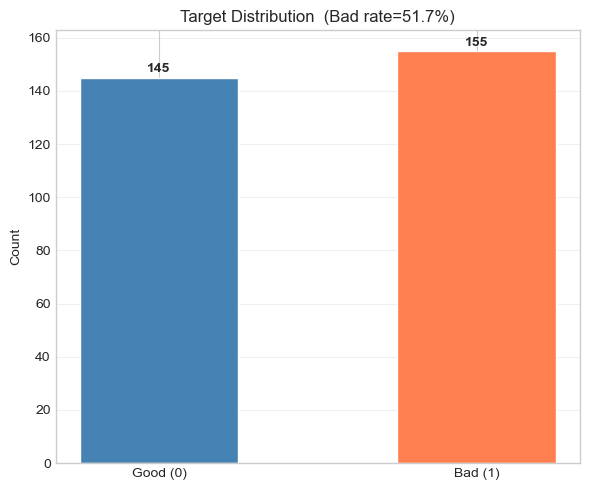

In [29]:
# Default = DPD>=90 in MOB 7-18
perf = dpd[(dpd['mob']>=7) & (dpd['mob']<=18)]
target = perf.groupby('loan_id')['dpd'].max().reset_index()
target['bad'] = (target['dpd'] >= 90).astype(int)

# Add settlements and write-offs
bad_ids = set(dfs['settle']['loan_id'].tolist()) | set(dfs['writeoff']['loan_id'].tolist())
target['bad'] = target.apply(
    lambda r: 1 if r['bad']==1 or r['loan_id'] in bad_ids else 0, axis=1)

print('Target Distribution:')
print(target['bad'].value_counts())
print(f'\nDefault Rate: {target["bad"].mean()*100:.2f}%')
print(f'  Loans in performance window: {len(target):,}')
print(f'  Bad (DPD90+ / Settled / WO): {target["bad"].sum():,}')
print(f'  Good:                         {(target["bad"]==0).sum():,}')

fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(['Good (0)', 'Bad (1)'], target['bad'].value_counts().sort_index(),
              color=['steelblue','coral'], edgecolor='white', width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+2,
            f'{b.get_height():,}', ha='center', fontweight='bold')
ax.set_title(f'Target Distribution  (Bad rate={target["bad"].mean()*100:.1f}%)')
ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/Data Analyst/Projects/Credit_Risk_Engine_Project/credit-risk-engine-v2/credit-risk-engine/models2/eda_target.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Correlation Matrix

In [33]:
try:
    model_df = pd.read_csv('../data/processed/model_dataset.csv')
    num_cols = model_df.select_dtypes(include=[np.number]).columns.tolist()
    drop_ids = ['loan_id','customer_id','application_id']
    num_cols = [c for c in num_cols if c not in drop_ids]
    
    corr = model_df[num_cols].corr()
    target_corr = corr['target_default'].drop('target_default').sort_values(key=abs, ascending=False).head(20)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['coral' if v>0 else 'steelblue' for v in target_corr.values]
    target_corr.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Top 20 Features — Correlation with Default Target')
    ax.set_xlabel('Pearson Correlation')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('D:/Data Analyst/Projects/Credit_Risk_Engine_Project/credit-risk-engine-v2/credit-risk-engine/models2/eda_correlations.png', dpi=120, bbox_inches='tight')
    plt.show()
except FileNotFoundError:
    print('Run create_features.py first to generate model_dataset.csv')

Run create_features.py first to generate model_dataset.csv


## 8. NPA & Settlement Summary

In [35]:
wo     = dfs['writeoff'].copy()
settle = dfs['settle'].copy()

wo['writeoff_amount'] = pd.to_numeric(wo['writeoff_amount'], errors='coerce').fillna(0)
wo['recovery_amount'] = pd.to_numeric(wo['recovery_amount'], errors='coerce').fillna(0)
settle['waiver_pct']  = pd.to_numeric(settle['waiver_percentage'], errors='coerce').fillna(0)

print('Write-off Summary:')
print(f'  Cases:          {len(wo)}')
print(f'  Total WO:       ₹{wo["writeoff_amount"].sum()/1e5:.2f}L')
print(f'  Total Recovery: ₹{wo["recovery_amount"].sum()/1e5:.2f}L')
print(f'  Recovery Rate:  {wo["recovery_amount"].sum()/max(wo["writeoff_amount"].sum(),1)*100:.1f}%')
print()
print('Settlement Summary:')
print(f'  Cases:          {len(settle)}')
print(f'  Avg Waiver:     {settle["waiver_pct"].mean():.1f}%')
print(f'  Min Waiver:     {settle["waiver_pct"].min():.1f}%')
print(f'  Max Waiver:     {settle["waiver_pct"].max():.1f}%')

Write-off Summary:
  Cases:          40
  Total WO:       ₹6507.51L
  Total Recovery: ₹1576.28L
  Recovery Rate:  24.2%

Settlement Summary:
  Cases:          30
  Avg Waiver:     44.2%
  Min Waiver:     15.6%
  Max Waiver:     69.1%
